## Web Scraping & Data Processing Pipeline

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Scraping The Data

In [19]:
from datalink.scraper import TGJUScraper

scraper = TGJUScraper(headless=True, max_pages=3) # collect data over past 3 months
raw_data = scraper.load_or_scrape()               # loads cached data upon subsequent executions

raw_data.head()

2026-08-27 11:26:15,608 - INFO - Reading cached data from D:\Source\svm-using-hmm\datalink\cache\gold18_history.csv


,Reopened,Lowest,Highest,Final,Change_Amount,Change_Percent,Date_Miladi,Date_Jalali
0,"183,221,000","183,201,000","197,711,000","197,631,000",10000,0.01%,2026/08/05,1405/05/14
1,"197,621,000","182,151,000","197,711,000","197,621,000",10000,0.01%,2026/08/04,1405/05/13
2,"197,621,000","183,281,000","197,711,000","197,631,000",50000,0.03%,2026/08/03,1405/05/12
3,"197,701,000","183,061,000","197,711,000","197,681,000",10020000,5.34%,2026/08/02,1405/05/11
4,"197,691,000","186,291,000","197,711,000","187,661,000",9970000,5.31%,2026/08/01,1405/05/10


### Processing & Calculating Log-Returns

In [20]:
from datalink.processor import calculate_tgju_log_returns

log_returns = raw_data.pipe(calculate_tgju_log_returns)

log_returns.head()

,Date,Final_F,Log_Return
0,2026/05/07,197661000.0,NaN
1,2026/05/08,197661000.0,0.000000
2,2026/05/09,197621000.0,-0.020239
3,2026/05/10,197631000.0,0.005060
4,2026/05/11,197651000.0,0.010119


## Parameter Estimation & VaR Calculation

### Data Prepration

In [21]:
log_returns_np = log_returns['Log_Return'].dropna().to_numpy()
log_returns_np

array([ 0.00000000e+00, -2.02387157e-02,  5.06006295e-03,  1.01193578e-02,
        0.00000000e+00, -1.51794208e-02,  0.00000000e+00,  2.02387157e-02,
       -2.02387157e-02,  0.00000000e+00,  0.00000000e+00,  2.02387157e-02,
       -2.02387157e-02,  5.06006295e-03,  0.00000000e+00,  2.52964748e-02,
       -2.52964748e-02,  3.03550020e-02, -3.54150649e-02,  0.00000000e+00,
        1.51794208e-02,  1.01183339e-02,  5.05878306e-03, -5.05878306e-03,
       -2.02376918e-02,  2.02376918e-02,  1.51755815e-02, -3.54132733e-02,
        0.00000000e+00,  4.04712887e-02, -1.01162867e-02,  1.01162867e-02,
       -2.02335969e-02, -2.52977547e-02, -1.16316024e+01,  1.16316024e+01,
       -1.19675439e+01, -6.42454043e+00, -3.55343141e+00,  3.34643107e+00,
       -3.13868261e+00,  1.46087340e+00,  6.48646916e-01, -2.89826677e-01,
       -6.81619434e-01,  6.07486325e-01, -9.89297123e-02,  5.05983395e-01,
        1.53755350e-01,  1.37932379e+00,  1.80925473e+01, -5.05827129e-03,
       -3.03550020e-02, -

### Model Parameter Fitting Based On Log-Returns

In [22]:
import numpy as np
from utils.datastructs import SVMParameters
from scipy import stats
from estimator import Hyperparameters, FastBayesianSVMEstimator

# 1. Define the SMN log-density function (e.g., Student-t distribution)
def student_t_logpdf(y: float, mu: np.ndarray, sigma: np.ndarray, nu: float) -> np.ndarray:
    """
    Log-density of the Student-t distribution parameterized by location, scale, and df.
    """
    # Using scipy stats, passing arrays for vectorized operations over the grid
    return stats.t.logpdf(y, df=nu, loc=mu, scale=sigma)

# 3. Configure Hyperparameters
config = Hyperparameters(
    m=150,               # Lowered to 50 for speed in MWE, paper uses 100-200
    b_limit=2.5,        # Grid boundaries
    is_samples=500      # Samples for IS
)

# 4. Instantiate and run the estimator
estimator = FastBayesianSVMEstimator(
    data=log_returns_np,
    smn_logpdf=student_t_logpdf,
    hyperparams=config
)

# 5. Extract Results
result = estimator.estimate()

print("\n--- ESTIMATION RESULTS ---")
print(f"Optimization Success: {result.success}")
print("\nPosterior Means (Constrained Space):")
for param, value in result.posterior_mean_con.items():
    print(f"{param:>10}: {value:.4f}")

params = SVMParameters(**result.map_estimate_con)

2026-08-27 11:26:16,011 - INFO - Starting numerical maximization (L-BFGS-B)...
d:\Source\svm-using-hmm\estimator.py:188: OptimizeWarning: Unknown solver options: disp
  opt_res = minimize(
2026-08-27 11:26:19,885 - INFO - MAP optimization complete. Unconstrained Mode: [ 3.000e-03 -4.181e+00  3.100e-02  3.050e-01  9.290e-01 -5.560e-01
 -4.575e+00]
2026-08-27 11:26:19,887 - INFO - Drawing 500 samples for Importance Sampling inference...
2026-08-27 11:26:27,538 - INFO - Importance Sampling complete.



--- ESTIMATION RESULTS ---
Optimization Success: True

Posterior Means (Constrained Space):
     beta0: 0.0249
     beta1: -0.9759
     beta2: -0.0647
        mu: 0.4334
       phi: 0.8014
 sigma_eta: 0.4886
        nu: 2.0033


### VaR Calculation

In [23]:
from var_calculator import (
    create_var_calculator,
)



# Construct the HMM-based VaR calculator.
calculator = create_var_calculator(
    parameters=params,
    model="t",
    lower=-2.5,
    upper=2.5,
    n_states=150,
)

var_5pct = calculator.calculate(
    log_returns_np,
    alpha=0.05,
)

var_5pct

array([         nan,  -3.57036332,  -3.40046166,  -3.3616939 ,
        -3.33946877,  -3.31793912,  -3.29823186,  -3.31079795,
        -3.32948483,  -3.28974709,  -3.30929844,  -3.3091367 ,
        -3.32876203,  -3.28943347,  -3.31401647,  -3.30904947,
        -3.33368041,  -3.28453652,  -3.3384723 ,  -3.27468469,
        -3.30938198,  -3.32394157,  -3.31903253,  -3.31404079,
        -3.30415527,  -3.28960723,  -3.32874081,  -3.32402548,
        -3.27494737,  -3.30950447,  -3.34885008,  -3.29964151,
        -3.31902138,  -3.28951552,  -3.28512925,   7.53707539,
       -14.79697323,   8.13310936,   2.40359692,  -0.51932263,
        -6.83001718,  -0.38453738,  -4.98330418,  -4.3084484 ,
        -3.21078326,  -2.84740191,  -3.98808444,  -3.2999928 ,
        -3.87409467,  -3.56497501,  -4.9005741 , -21.42162522,
        -4.00910639,  -3.57146542,   9.75287313, -17.24275907,
         6.26891168, -13.53726838,   6.80800416, -13.66324266,
        -3.79017327,   5.87872277, -13.42394477,   7.09

In [24]:
log_returns_np.shape

(89,)

In [25]:
len(var_5pct)

89

## Data Visualization & EDA

C:\Users\CHAMPION\AppData\Local\Temp\ipykernel_9864\1860738491.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  create_var_violation_plot(dates, log_returns_np, var_5pct, shift_steps=0).show()


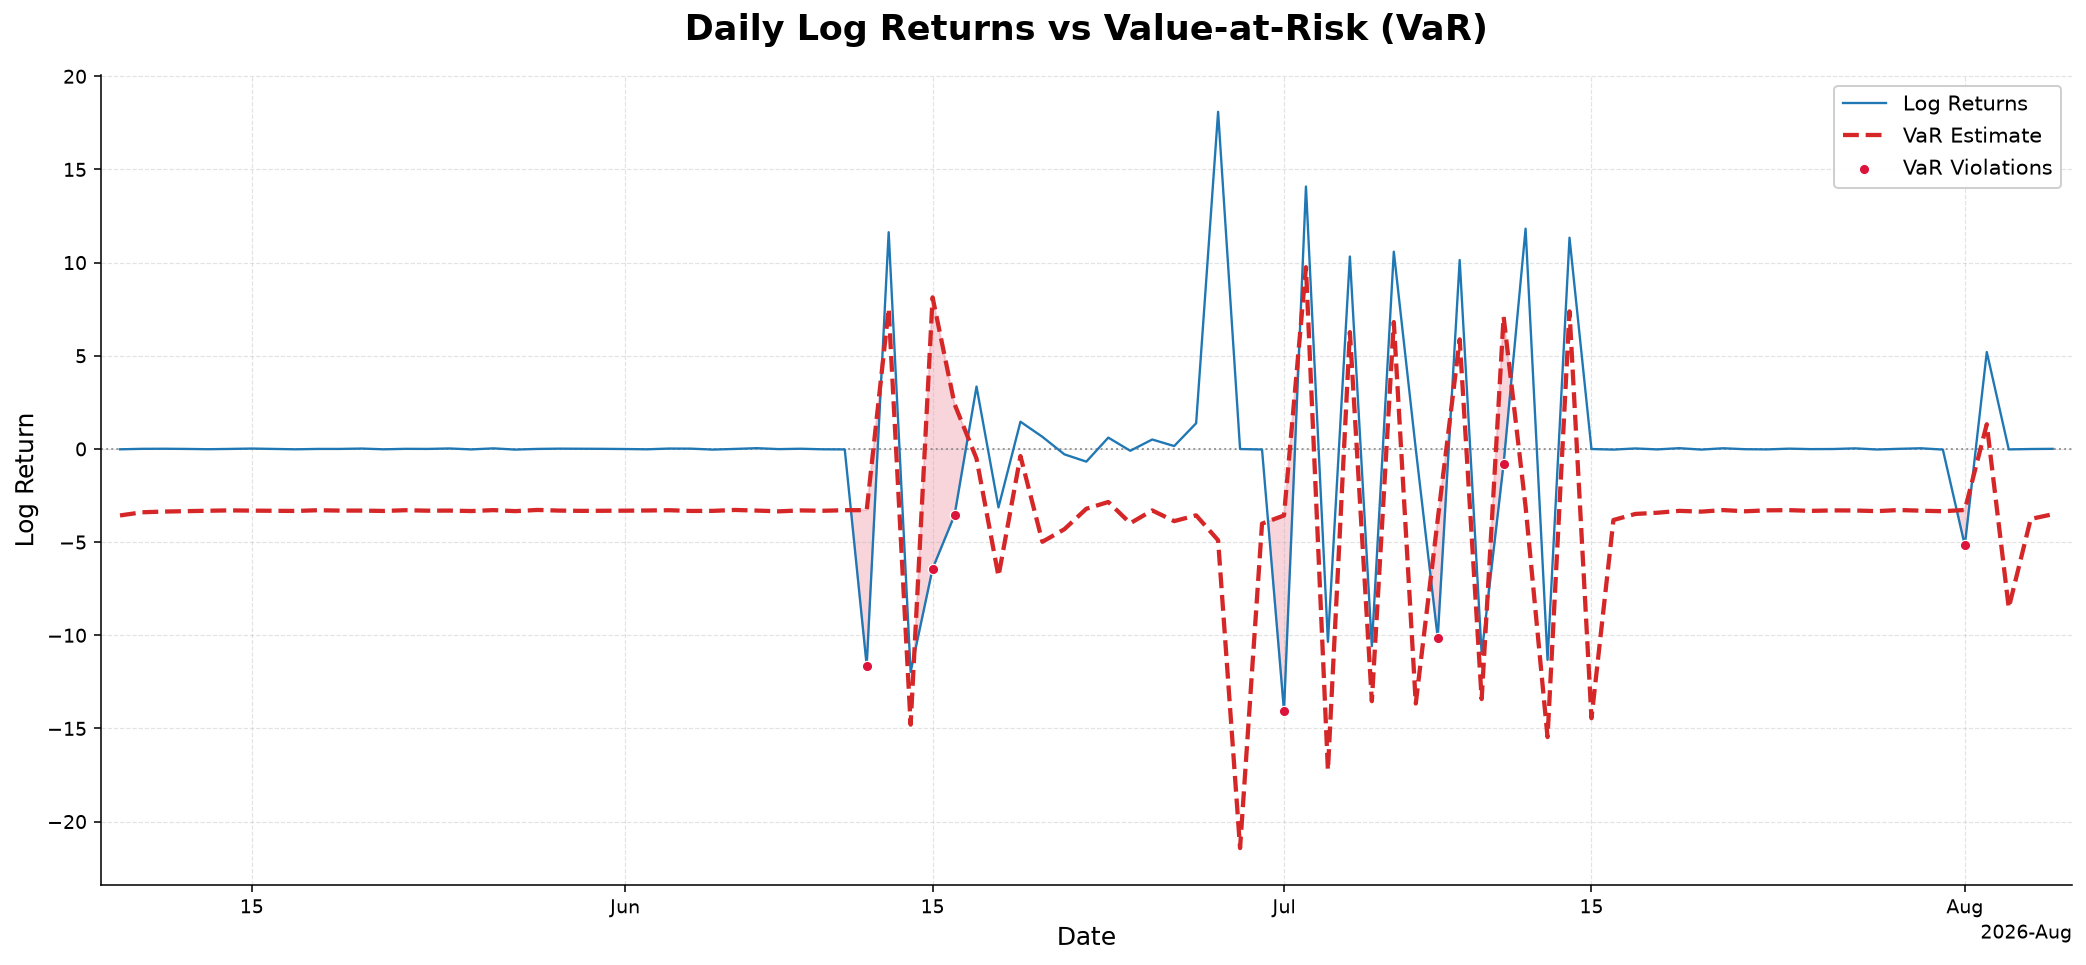

In [26]:
import pandas as pd
from utils.presentation import create_var_violation_plot

# -----------------------------
# Prepare data
# -----------------------------
dates = pd.to_datetime(log_returns["Date"].iloc[1:]).reset_index(drop=True)

create_var_violation_plot(dates, log_returns_np, var_5pct, shift_steps=0).show()

### Violation Rates

In [27]:
violations = log_returns_np < var_5pct

violation_rate = violations[~np.isnan(var_5pct)].mean()

print(f"Observed violation rate: {violation_rate:.4%}")

Observed violation rate: 7.9545%
